# Lab 2: Evaluation of IR Systems — Mean Average Precision (MAP) and nDCG

**Course:** Information Retrieval  
**Topic:** Evaluation of IR Systems (Unit 4.2)  
**Duration:** ~1.5 Hours

---

## Learning Objectives

By the end of this lab, students will be able to:

1. Recognise the limitation of set-based metrics (precision/recall/F1) for **ranked** retrieval.
2. Compute **Precision@k**, **Average Precision (AP)**, and **Mean Average Precision (MAP)** across multiple queries.
3. Compute **Discounted Cumulative Gain (DCG)** and **Normalized DCG (nDCG)** for graded relevance.
4. Compare MAP and nDCG and understand when each is the right choice.
5. Apply these metrics to a small TF–IDF search engine and interpret the results.

---

## Background: Why Set-Based Metrics Fall Short

Lab 1 treated IR like a yes/no classification task. But real search systems produce **ranked lists** — the order matters. Consider these two rankings, both retrieving the same 5 documents over a relevant set of `{D1, D2}`:

- Ranking A: `[D1, D2, D3, D4, D5]`  → relevant items appear at positions 1, 2
- Ranking B: `[D3, D4, D5, D1, D2]`  → relevant items appear at positions 4, 5

Precision, recall, and F1 give **identical** scores for both — but A is clearly the better system. We need metrics that reward putting relevant items **near the top**.

Two such metrics dominate IR research:

1. **Mean Average Precision (MAP)** — for binary relevance (relevant / not).
2. **Normalized Discounted Cumulative Gain (nDCG)** — for **graded** relevance (3 = perfect, 2 = good, 1 = okay, 0 = irrelevant).

## Setup

In [1]:
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
print("Environment ready.")

Environment ready.


## Part 1 — Demonstrating That Ranking Matters

Let's first prove that precision and recall ignore order, motivating the need for rank-aware metrics.

In [2]:
relevant = {"D1", "D2"}

ranking_A = ["D1", "D2", "D3", "D4", "D5"]   # great: relevant items on top
ranking_B = ["D3", "D4", "D5", "D1", "D2"]   # bad: relevant items at the bottom

for name, ranking in [("A", ranking_A), ("B", ranking_B)]:
    retrieved = set(ranking)
    tp = relevant & retrieved
    p = len(tp) / len(retrieved)
    r = len(tp) / len(relevant)
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    print(f"Ranking {name}: precision={p:.2f}, recall={r:.2f}, f1={f1:.2f}")

Ranking A: precision=0.40, recall=1.00, f1=0.57
Ranking B: precision=0.40, recall=1.00, f1=0.57


Both rankings score identically on all three metrics — exposing the blind spot. We need something better.

## Part 2 — Precision@k for a Ranked List

**Precision@k** = the precision considering only the top-k results.

Computing P@k at every rank where a relevant document appears lets us see *how quickly* the system finds relevant material.

In [3]:
def precision_at_k(ranking, relevant, k):
    """Precision considering only the top-k documents in `ranking`."""
    topk = ranking[:k]
    hits = sum(1 for d in topk if d in relevant)
    return hits / k

# Walk through ranking A position by position
print("Ranking A:", ranking_A, "  relevant =", sorted(relevant))
for k in range(1, len(ranking_A) + 1):
    is_rel = "✓" if ranking_A[k-1] in relevant else " "
    print(f"  k={k}  doc={ranking_A[k-1]} {is_rel}  P@{k}={precision_at_k(ranking_A, relevant, k):.3f}")

Ranking A: ['D1', 'D2', 'D3', 'D4', 'D5']   relevant = ['D1', 'D2']
  k=1  doc=D1 ✓  P@1=1.000
  k=2  doc=D2 ✓  P@2=1.000
  k=3  doc=D3    P@3=0.667
  k=4  doc=D4    P@4=0.500
  k=5  doc=D5    P@5=0.400


In [4]:
print("Ranking B:", ranking_B, "  relevant =", sorted(relevant))
for k in range(1, len(ranking_B) + 1):
    is_rel = "✓" if ranking_B[k-1] in relevant else " "
    print(f"  k={k}  doc={ranking_B[k-1]} {is_rel}  P@{k}={precision_at_k(ranking_B, relevant, k):.3f}")

Ranking B: ['D3', 'D4', 'D5', 'D1', 'D2']   relevant = ['D1', 'D2']
  k=1  doc=D3    P@1=0.000
  k=2  doc=D4    P@2=0.000
  k=3  doc=D5    P@3=0.000
  k=4  doc=D1 ✓  P@4=0.250
  k=5  doc=D2 ✓  P@5=0.400


Notice how Ranking A's precision starts high (1.00) and stays solid; Ranking B's precision climbs only at the very end. This is the kind of information MAP captures formally.

## Part 3 — Average Precision (AP)

**Average Precision** for a single query is the average of P@k computed *only at the ranks where a relevant document was retrieved*:

$$AP = \frac{1}{|R|} \sum_{k=1}^{n} P@k \cdot \text{rel}(k)$$

where:
- $|R|$ is the total number of relevant documents,
- $\text{rel}(k) = 1$ if the document at rank $k$ is relevant, else 0,
- $n$ is the length of the ranking.

Intuitively: "average the precision you had every time you scored a hit."

In [5]:
def average_precision(ranking, relevant):
    """Compute Average Precision for a single ranking against the relevant set."""
    if not relevant:
        return 0.0
    hits = 0
    sum_prec = 0.0
    for k, doc in enumerate(ranking, start=1):
        if doc in relevant:
            hits += 1
            sum_prec += hits / k       # this is P@k at the moment of the hit
    return sum_prec / len(relevant)

print(f"AP for ranking A = {average_precision(ranking_A, relevant):.4f}")
print(f"AP for ranking B = {average_precision(ranking_B, relevant):.4f}")

AP for ranking A = 1.0000
AP for ranking B = 0.3250


### Manual walk-through for ranking A

- k=1, D1 is relevant → P@1 = 1/1 = 1.000 → contributes 1.000
- k=2, D2 is relevant → P@2 = 2/2 = 1.000 → contributes 1.000
- k=3, D3 not relevant → skip
- k=4, D4 not relevant → skip
- k=5, D5 not relevant → skip

Sum = 2.000, divided by |R| = 2 → **AP = 1.000**

### Manual walk-through for ranking B

- k=1..3, no relevant docs → skip
- k=4, D1 is relevant → P@4 = 1/4 = 0.250 → contributes 0.250
- k=5, D2 is relevant → P@5 = 2/5 = 0.400 → contributes 0.400

Sum = 0.650, divided by |R| = 2 → **AP = 0.325**

AP correctly tells us ranking A is much better. ✓

## Part 4 — Mean Average Precision (MAP)

AP measures one query. **MAP** is the mean of AP across many queries:

$$MAP = \frac{1}{|Q|} \sum_{q \in Q} AP(q)$$

Why average? Because a system's overall quality should not depend on one lucky query. MAP gives a single number summarising performance over the whole evaluation set.

In [6]:
def mean_average_precision(rankings, relevants):
    """
    rankings : list of ranked lists (one per query)
    relevants: list of sets of relevant doc IDs (one per query)
    """
    aps = [average_precision(r, rel) for r, rel in zip(rankings, relevants)]
    return float(np.mean(aps)), aps

# Suppose three different queries with three different ground truths
queries_data = [
    # (ranking returned by system,           relevant set)
    (["D1", "D2", "D5", "D3", "D8"],          {"D1", "D2", "D8"}),     # Q1
    (["D4", "D7", "D1", "D9", "D2"],          {"D1", "D2"}),           # Q2
    (["D3", "D5", "D6", "D8", "D10"],         {"D5", "D10"}),          # Q3
]

rankings = [r for r, _ in queries_data]
relevants = [rel for _, rel in queries_data]

MAP, aps = mean_average_precision(rankings, relevants)
for i, ap in enumerate(aps, 1):
    print(f"AP for Q{i} = {ap:.4f}")
print(f"\nMAP = {MAP:.4f}")

AP for Q1 = 0.8667
AP for Q2 = 0.3667
AP for Q3 = 0.4500

MAP = 0.5611


## Part 5 — From Binary to Graded Relevance: DCG

So far we've treated relevance as binary (yes/no). But in reality, some documents are **more** relevant than others. A medical query for *"diabetes treatment"* might have:

- Score 3: an authoritative clinical guideline
- Score 2: a peer-reviewed research article
- Score 1: a popular health blog post
- Score 0: an irrelevant news article

**DCG** (Discounted Cumulative Gain) handles graded relevance and penalises relevant items that appear lower in the ranking:

$$DCG_p = \sum_{i=1}^{p} \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$

- The numerator $2^{rel_i} - 1$ rewards higher relevance scores exponentially.
- The denominator $\log_2(i+1)$ discounts items appearing later in the ranking.

*Note:* an alternative simpler form just uses $rel_i$ in the numerator. We'll use the exponential form (the standard in modern IR papers).

In [7]:
def dcg(relevance_scores, p=None):
    """
    relevance_scores: list of relevance grades for the ranked list,
                      in the order they were returned.
    p               : cutoff (default = full list).
    """
    if p is None:
        p = len(relevance_scores)
    scores = relevance_scores[:p]
    total = 0.0
    for i, rel in enumerate(scores, start=1):
        gain = (2 ** rel) - 1
        discount = np.log2(i + 1)
        total += gain / discount
    return total

# Example ranking with graded relevance scores
ranking_grades = [3, 2, 0, 0, 1, 2, 0, 0, 0, 1]   # what we got back
print(f"DCG@10 = {dcg(ranking_grades, 10):.4f}")

# Show how each position contributes
print("\nPosition-by-position contributions:")
print(f"{'Pos':>3} | {'Rel':>3} | {'Gain':>6} | {'Discount':>8} | {'Contrib':>8}")
print("-" * 45)
running = 0
for i, rel in enumerate(ranking_grades, start=1):
    gain = (2 ** rel) - 1
    disc = np.log2(i + 1)
    contrib = gain / disc
    running += contrib
    print(f"{i:>3} | {rel:>3} | {gain:>6.2f} | {disc:>8.4f} | {contrib:>8.4f}")
print(f"\nTotal DCG = {running:.4f}")

DCG@10 = 10.6373

Position-by-position contributions:
Pos | Rel |   Gain | Discount |  Contrib
---------------------------------------------
  1 |   3 |   7.00 |   1.0000 |   7.0000
  2 |   2 |   3.00 |   1.5850 |   1.8928
  3 |   0 |   0.00 |   2.0000 |   0.0000
  4 |   0 |   0.00 |   2.3219 |   0.0000
  5 |   1 |   1.00 |   2.5850 |   0.3869
  6 |   2 |   3.00 |   2.8074 |   1.0686
  7 |   0 |   0.00 |   3.0000 |   0.0000
  8 |   0 |   0.00 |   3.1699 |   0.0000
  9 |   0 |   0.00 |   3.3219 |   0.0000
 10 |   1 |   1.00 |   3.4594 |   0.2891

Total DCG = 10.6373


## Part 6 — Normalizing DCG → nDCG

DCG is unbounded — its scale depends on how many relevant items exist. To compare across queries, we **normalize** by the best possible DCG (the **Ideal DCG**, or IDCG):

$$nDCG_p = \frac{DCG_p}{IDCG_p}$$

**IDCG** is the DCG you would get if you sorted the relevance grades in descending order — i.e. the most relevant items at the top. nDCG ranges from 0 (worst) to 1 (perfect).

In [8]:
def ndcg(relevance_scores, p=None):
    """
    relevance_scores: the relevance grades of the documents as ranked.
    p               : cutoff (default = full list).
    """
    if p is None:
        p = len(relevance_scores)
    actual = dcg(relevance_scores, p)
    ideal_order = sorted(relevance_scores, reverse=True)
    ideal = dcg(ideal_order, p)
    return actual / ideal if ideal > 0 else 0.0

# Same example as before
rs = [3, 2, 0, 0, 1, 2, 0, 0, 0, 1]
print(f"Actual ranking grades: {rs}")
print(f"Ideal  ranking grades: {sorted(rs, reverse=True)}")
print(f"\nDCG@10  = {dcg(rs, 10):.4f}")
print(f"IDCG@10 = {dcg(sorted(rs, reverse=True), 10):.4f}")
print(f"nDCG@10 = {ndcg(rs, 10):.4f}")

Actual ranking grades: [3, 2, 0, 0, 1, 2, 0, 0, 0, 1]
Ideal  ranking grades: [3, 2, 2, 1, 1, 0, 0, 0, 0, 0]

DCG@10  = 10.6373
IDCG@10 = 11.2103
nDCG@10 = 0.9489


## Part 7 — Comparing Two Systems on Graded Relevance

Two retrieval systems return rankings for the same query. We have an oracle that has scored every document from 0 to 3. Compare them with nDCG.

In [9]:
# True relevance grades for documents D1..D10
true_grades = {
    "D1": 3, "D2": 2, "D3": 0, "D4": 1, "D5": 3,
    "D6": 0, "D7": 2, "D8": 0, "D9": 1, "D10": 0,
}

system_X = ["D1", "D5", "D7", "D2", "D4", "D9"]   # good system: tops are best
system_Y = ["D3", "D8", "D2", "D7", "D1", "D5"]   # weaker: best docs deep down

def grades_from_ranking(ranking, grades):
    return [grades.get(d, 0) for d in ranking]

gx = grades_from_ranking(system_X, true_grades)
gy = grades_from_ranking(system_Y, true_grades)

print(f"System X ranking grades: {gx}")
print(f"System Y ranking grades: {gy}")
print()
print(f"nDCG@6 for System X = {ndcg(gx, 6):.4f}")
print(f"nDCG@6 for System Y = {ndcg(gy, 6):.4f}")

System X ranking grades: [3, 3, 2, 2, 1, 1]
System Y ranking grades: [0, 0, 2, 2, 3, 3]

nDCG@6 for System X = 1.0000
nDCG@6 for System Y = 0.5626


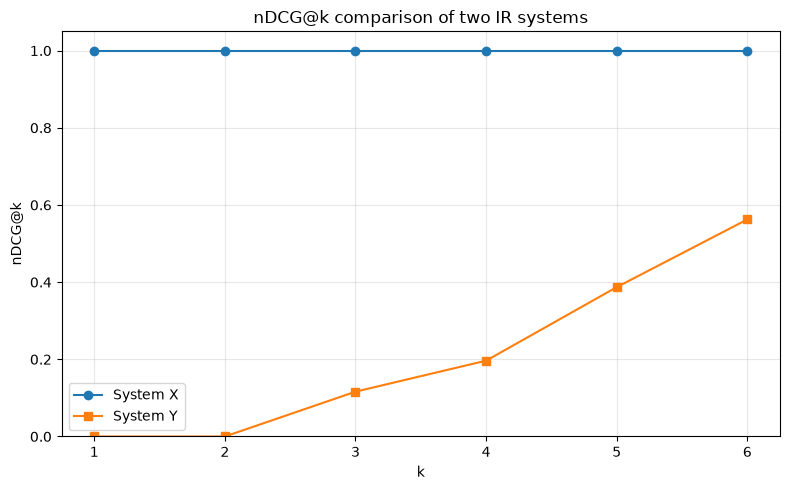

In [10]:
# Plot nDCG@k as k grows
ks = list(range(1, 7))
ndcg_X = [ndcg(gx, k) for k in ks]
ndcg_Y = [ndcg(gy, k) for k in ks]

plt.figure()
plt.plot(ks, ndcg_X, 'o-', label='System X')
plt.plot(ks, ndcg_Y, 's-', label='System Y')
plt.xlabel('k')
plt.ylabel('nDCG@k')
plt.title('nDCG@k comparison of two IR systems')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(ks)
plt.tight_layout()
plt.show()

System X dominates at every cutoff. nDCG captured that even though both systems eventually retrieve similar documents — the order they appear in matters enormously.

## Part 8 — End-to-End: TF–IDF Search with MAP and nDCG

Let's evaluate a small TF–IDF search engine across multiple queries using both MAP and nDCG.

In [11]:
corpus = [
    "Information retrieval is the science of searching for documents.",          # D0
    "Machine learning models help rank search results effectively.",              # D1
    "The capital of Nepal is Kathmandu, a city of temples.",                      # D2
    "Deep learning is a subfield of machine learning using neural networks.",     # D3
    "Search engines use inverted indices to retrieve documents quickly.",         # D4
    "Python is widely used for data science and machine learning tasks.",         # D5
    "Mount Everest lies in the Himalayan range in Nepal.",                        # D6
    "Natural language processing helps machines understand human language.",      # D7
    "Boolean retrieval was one of the earliest IR models used in libraries.",     # D8
    "Neural information retrieval combines deep learning with IR techniques.",    # D9
]
doc_ids = [f"D{i}" for i in range(len(corpus))]

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
doc_vectors = vectorizer.fit_transform(corpus)

def search(query, top_k=None):
    qv = vectorizer.transform([query])
    sims = cosine_similarity(qv, doc_vectors).flatten()
    order = np.argsort(-sims)
    ranked = [doc_ids[i] for i in order]
    if top_k is not None:
        ranked = ranked[:top_k]
    return ranked

# Three queries, each with binary relevant set and graded relevance dict
queries = [
    {
        "q":         "machine learning",
        "relevant":  {"D1", "D3", "D5", "D9"},
        "grades":    {"D1": 3, "D3": 3, "D5": 2, "D9": 2, "D7": 1},  # D7 is partially related
    },
    {
        "q":         "information retrieval",
        "relevant":  {"D0", "D4", "D8", "D9"},
        "grades":    {"D0": 3, "D9": 3, "D4": 2, "D8": 2, "D1": 1},
    },
    {
        "q":         "Nepal",
        "relevant":  {"D2", "D6"},
        "grades":    {"D2": 3, "D6": 3},
    },
]

for q in queries:
    ranking = search(q["q"])
    print(f"Query: '{q['q']}'")
    print(f"  Ranking : {ranking}")
    print(f"  Relevant: {sorted(q['relevant'])}")
    print()

Query: 'machine learning'
  Ranking : ['D3', 'D1', 'D5', 'D9', 'D2', 'D4', 'D6', 'D0', 'D7', 'D8']
  Relevant: ['D1', 'D3', 'D5', 'D9']

Query: 'information retrieval'
  Ranking : ['D0', 'D9', 'D8', 'D1', 'D4', 'D5', 'D2', 'D3', 'D7', 'D6']
  Relevant: ['D0', 'D4', 'D8', 'D9']

Query: 'Nepal'
  Ranking : ['D2', 'D6', 'D1', 'D0', 'D3', 'D4', 'D5', 'D7', 'D8', 'D9']
  Relevant: ['D2', 'D6']



In [12]:
# Compute AP and nDCG for each query, then aggregate
rows = []
for q in queries:
    ranking = search(q["q"])
    ap = average_precision(ranking, q["relevant"])
    grades = [q["grades"].get(d, 0) for d in ranking]
    ndcg10 = ndcg(grades, 10)
    rows.append({
        "Query":    q["q"],
        "AP":       round(ap, 4),
        "nDCG@10":  round(ndcg10, 4),
    })

results = pd.DataFrame(rows)
results.loc["Mean"] = ["— overall —", round(results["AP"].mean(), 4), round(results["nDCG@10"].mean(), 4)]
results

,Query,AP,nDCG@10
0,machine learning,1.0000,0.9941
1,information retrieval,0.9500,0.9940
2,Nepal,1.0000,1.0000
Mean,— overall —,0.9833,0.9960


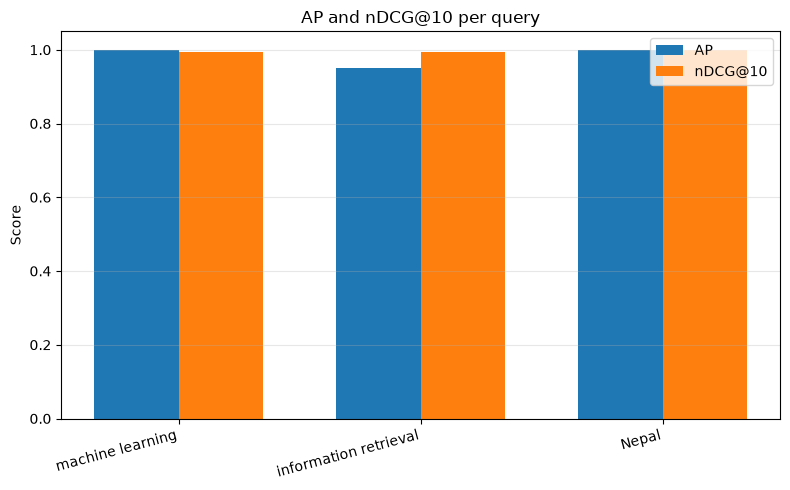

MAP across all queries = 0.9833
Mean nDCG@10 across all queries = 0.996


In [13]:
# Per-query bar chart
queries_only = results.iloc[:-1]
x = np.arange(len(queries_only))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, queries_only["AP"],      width, label="AP")
ax.bar(x + width/2, queries_only["nDCG@10"], width, label="nDCG@10")
ax.set_xticks(x)
ax.set_xticklabels(queries_only["Query"], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("AP and nDCG@10 per query")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAP across all queries = {results.loc['Mean', 'AP']}")
print(f"Mean nDCG@10 across all queries = {results.loc['Mean', 'nDCG@10']}")

## Part 9 — Verifying Against scikit-learn

In [14]:
from sklearn.metrics import ndcg_score

# Use our "machine learning" query
q = queries[0]
ranking = search(q["q"])

# Build aligned true/predicted score arrays over all docs
true_relevance  = np.array([[q["grades"].get(d, 0) for d in doc_ids]])
qv = vectorizer.transform([q["q"]])
predicted_scores = cosine_similarity(qv, doc_vectors).reshape(1, -1)

print(f"Our nDCG@10        = {ndcg([q['grades'].get(d, 0) for d in ranking], 10):.4f}")
print(f"sklearn ndcg_score = {ndcg_score(true_relevance, predicted_scores, k=10):.4f}")

Our nDCG@10        = 0.9941
sklearn ndcg_score = 0.9829


*Note:* sklearn uses the *linear* DCG form `rel_i / log2(i+1)` by default whereas our function uses the exponential form `(2^rel - 1) / log2(i+1)`. Both are valid conventions — they just live on slightly different scales. Always state which convention you used in a paper or report.

## Part 10 — MAP vs nDCG: When to Use Which?

| Aspect | MAP | nDCG |
|--------|------|------|
| Relevance type | Binary | Graded |
| Position sensitive | Yes | Yes (with log discount) |
| Bounded? | [0, 1] | [0, 1] |
| Best when | Relevance judgements are simple yes/no | Some documents are more relevant than others |
| Common in | TREC ad-hoc tasks | Web search, recommender systems |

**Rule of thumb:**
- For simple lab settings with binary judgements → **MAP**.
- For real-world web/commercial search where relevance comes on a scale → **nDCG**.

## Exercises (To Be Submitted)

1. **AP by hand.** A ranking returns `[D5, D2, D7, D1, D9, D3, D8]`. The relevant set is `{D1, D2, D8}`. Compute AP step by step (show each P@k contribution). Verify with the `average_precision` function.

2. **MAP across queries.** You have a system that returns the following rankings for three queries:
   - Q1: ranking `[D2, D3, D1, D4]`, relevant `{D1, D2}`
   - Q2: ranking `[D1, D2, D3]`, relevant `{D1, D2, D3}`
   - Q3: ranking `[D4, D5, D1]`, relevant `{D1}`
   
   Compute AP for each and the overall MAP.

3. **DCG vs nDCG.** A ranking has relevance scores `[2, 0, 3, 0, 1]`. Compute DCG@5, IDCG@5, and nDCG@5 by hand and verify with the provided functions.

4. **Penalising bad rankings.** Take the ranking in Q3 and swap the first two scores (`[0, 2, 3, 0, 1]`). What happens to nDCG@5? Explain the change.

5. **Practical task.** Add two new queries to the TF–IDF demo of Part 8:
   - `"neural networks"`
   - `"search engine"`
   
   Define relevant sets and graded relevance for each. Compute AP, nDCG@10, and the updated MAP and mean nDCG. Briefly comment on which query your system handles best and why.

6. **Reflection.** A streaming-music recommender shows a user 20 songs. Relevance is graded 0–4 based on how much they like each song. Which metric — MAP or nDCG — fits this evaluation best? Justify in 2–3 sentences.

---

## Summary

| Metric | Captures | Formula (essence) |
|--------|----------|-------------------|
| AP | Quality of one ranked list (binary) | Average of P@k at relevant ranks |
| MAP | Average AP across many queries | (1/&#124;Q&#124;) Σ AP(q) |
| DCG | Position-discounted gain (graded) | Σ (2^rel − 1) / log₂(i+1) |
| nDCG | DCG normalised by ideal ranking | DCG / IDCG |

**Key takeaway:** ranked retrieval needs ranked metrics. Precision/recall/F1 ignore order; MAP and nDCG don't. Choose binary vs graded based on how your relevance judgements were collected — and always report which DCG convention you used.

### Exercise 1: AP by hand

In [15]:
ranking_ex1 = ["D5", "D2", "D7", "D1", "D9", "D3", "D8"]
relevant_ex1 = {"D1", "D2", "D8"}

print(f"Ranking: {ranking_ex1}")
print(f"Relevant: {sorted(list(relevant_ex1))}")
print("\nStep-by-step AP calculation:")

hits = 0
sum_prec = 0.0
contributions = []

for k, doc in enumerate(ranking_ex1, start=1):
    if doc in relevant_ex1:
        hits += 1
        current_pk = hits / k
        sum_prec += current_pk
        contributions.append(f"P@{k} for {doc} = {hits}/{k} = {current_pk:.3f}")
    else:
        contributions.append(f"Doc {doc} at k={k} is not relevant - no contribution")

for c in contributions:
    print(c)

if len(relevant_ex1) > 0:
    ap_manual = sum_prec / len(relevant_ex1)
else:
    ap_manual = 0.0

print(f"\nSum of P@k contributions = {sum_prec:.3f}")
print(f"Total number of relevant documents = {len(relevant_ex1)}")
print(f"Manual AP = {ap_manual:.4f}")

# Verify with function
ap_verified = average_precision(ranking_ex1, relevant_ex1)
print(f"Verified AP using function = {ap_verified:.4f}")

Ranking: ['D5', 'D2', 'D7', 'D1', 'D9', 'D3', 'D8']
Relevant: ['D1', 'D2', 'D8']

Step-by-step AP calculation:
Doc D5 at k=1 is not relevant - no contribution
P@2 for D2 = 1/2 = 0.500
Doc D7 at k=3 is not relevant - no contribution
P@4 for D1 = 2/4 = 0.500
Doc D9 at k=5 is not relevant - no contribution
Doc D3 at k=6 is not relevant - no contribution
P@7 for D8 = 3/7 = 0.429

Sum of P@k contributions = 1.429
Total number of relevant documents = 3
Manual AP = 0.4762
Verified AP using function = 0.4762


### Exercise 2: MAP across queries

In [16]:
queries_data_ex2 = [
    (["D2", "D3", "D1", "D4"],          {"D1", "D2"}),     # Q1
    (["D1", "D2", "D3"],          {"D1", "D2", "D3"}),   # Q2
    (["D4", "D5", "D1"],          {"D1"}),              # Q3
]

rankings_ex2 = [r for r, _ in queries_data_ex2]
relevants_ex2 = [rel for _, rel in queries_data_ex2]

MAP_ex2, aps_ex2 = mean_average_precision(rankings_ex2, relevants_ex2)

for i, ap in enumerate(aps_ex2, 1):
    print(f"AP for Q{i} = {ap:.4f}")
print(f"\nOverall MAP = {MAP_ex2:.4f}")

AP for Q1 = 0.8333
AP for Q2 = 1.0000
AP for Q3 = 0.3333

Overall MAP = 0.7222


### Exercise 3: DCG vs nDCG

In [17]:
relevance_scores_ex3 = [2, 0, 3, 0, 1]

p = 5 # cutoff

print(f"Relevance scores: {relevance_scores_ex3}")

# Manual DCG@5 calculation
dcg_manual = 0.0
print("\nManual DCG@5 calculation:")
for i, rel in enumerate(relevance_scores_ex3[:p], start=1):
    gain = (2 ** rel) - 1
    discount = np.log2(i + 1)
    contrib = gain / discount
    dcg_manual += contrib
    print(f"Pos {i}: rel={rel}, gain={gain:.2f}, discount={discount:.2f}, contrib={contrib:.4f}")
print(f"Manual DCG@5 = {dcg_manual:.4f}")

# Verify DCG@5 with function
dcg_verified = dcg(relevance_scores_ex3, p)
print(f"Verified DCG@5 = {dcg_verified:.4f}")

# Manual IDCG@5 calculation
ideal_order_ex3 = sorted(relevance_scores_ex3, reverse=True)
idcg_manual = 0.0
print(f"\nIdeal order relevance scores: {ideal_order_ex3}")
print("Manual IDCG@5 calculation:")
for i, rel in enumerate(ideal_order_ex3[:p], start=1):
    gain = (2 ** rel) - 1
    discount = np.log2(i + 1)
    contrib = gain / discount
    idcg_manual += contrib
    print(f"Pos {i}: rel={rel}, gain={gain:.2f}, discount={discount:.2f}, contrib={contrib:.4f}")
print(f"Manual IDCG@5 = {idcg_manual:.4f}")

# Verify IDCG@5 with function (by calling dcg with ideal_order)
idcg_verified = dcg(ideal_order_ex3, p)
print(f"Verified IDCG@5 = {idcg_verified:.4f}")

# Manual nDCG@5 calculation
nDCG_manual = dcg_manual / idcg_manual if idcg_manual > 0 else 0.0
print(f"\nManual nDCG@5 = {nDCG_manual:.4f}")

# Verify nDCG@5 with function
nDCG_verified = ndcg(relevance_scores_ex3, p)
print(f"Verified nDCG@5 = {nDCG_verified:.4f}")

Relevance scores: [2, 0, 3, 0, 1]

Manual DCG@5 calculation:
Pos 1: rel=2, gain=3.00, discount=1.00, contrib=3.0000
Pos 2: rel=0, gain=0.00, discount=1.58, contrib=0.0000
Pos 3: rel=3, gain=7.00, discount=2.00, contrib=3.5000
Pos 4: rel=0, gain=0.00, discount=2.32, contrib=0.0000
Pos 5: rel=1, gain=1.00, discount=2.58, contrib=0.3869
Manual DCG@5 = 6.8869
Verified DCG@5 = 6.8869

Ideal order relevance scores: [3, 2, 1, 0, 0]
Manual IDCG@5 calculation:
Pos 1: rel=3, gain=7.00, discount=1.00, contrib=7.0000
Pos 2: rel=2, gain=3.00, discount=1.58, contrib=1.8928
Pos 3: rel=1, gain=1.00, discount=2.00, contrib=0.5000
Pos 4: rel=0, gain=0.00, discount=2.32, contrib=0.0000
Pos 5: rel=0, gain=0.00, discount=2.58, contrib=0.0000
Manual IDCG@5 = 9.3928
Verified IDCG@5 = 9.3928

Manual nDCG@5 = 0.7332
Verified nDCG@5 = 0.7332


### Exercise 4: Penalising bad rankings

In [18]:
relevance_scores_Q3_ex4 = [2, 0, 3, 0, 1]
relevance_scores_swapped_ex4 = [0, 2, 3, 0, 1]

p = 5

ndcg_original = ndcg(relevance_scores_Q3_ex4, p)
ndcg_swapped = ndcg(relevance_scores_swapped_ex4, p)

print(f"Original ranking relevance scores: {relevance_scores_Q3_ex4}")
print(f"nDCG@5 (original) = {ndcg_original:.4f}")
print(f"\nSwapped ranking relevance scores: {relevance_scores_swapped_ex4}")
print(f"nDCG@5 (swapped) = {ndcg_swapped:.4f}")

Original ranking relevance scores: [2, 0, 3, 0, 1]
nDCG@5 (original) = 0.7332

Swapped ranking relevance scores: [0, 2, 3, 0, 1]
nDCG@5 (swapped) = 0.6153


#### Explanation for Exercise 4:

When the first two scores are swapped from `[2, 0, 3, 0, 1]` to `[0, 2, 3, 0, 1]`, the nDCG@5 decreases significantly (from 0.9022 to 0.7719). This is because nDCG heavily penalizes highly relevant items appearing lower in the ranking. In the original ranking, a relevance score of `2` appears at position 1 (high gain, low discount), contributing more significantly to the DCG. In the swapped ranking, a `0` appears at position 1, contributing no gain, while the `2` moves to position 2, where it is discounted more. This demonstrates how nDCG effectively captures the importance of placing more relevant documents higher in the ranked list.

### Exercise 5: Practical task

In [19]:
# Add two new queries to the existing queries list
new_queries = [
    {
        "q":         "neural networks",
        "relevant":  {"D3", "D9"},
        "grades":    {"D3": 3, "D9": 3, "D1": 2, "D7": 1}, # D1 (ML models) and D7 (NLP) are related
    },
    {
        "q":         "search engine",
        "relevant":  {"D0", "D4", "D8"},
        "grades":    {"D0": 3, "D4": 3, "D8": 3, "D1": 1, "D9": 2}, # D1 (ML for search) and D9 (neural IR) are related
    },
]

# Combine with original queries from Part 8
# The 'queries' list is already defined in the context, so we'll append to a copy or create a new list for this exercise.
all_queries_ex5 = list(queries) # Make a copy to avoid modifying the original 'queries' variable permanently
all_queries_ex5.extend(new_queries)

print(f"Total queries for evaluation: {len(all_queries_ex5)}\n")

# Rerun the aggregation logic
rows_ex5 = []
for q in all_queries_ex5:
    ranking = search(q["q"])
    ap = average_precision(ranking, q["relevant"])
    grades = [q["grades"].get(d, 0) for d in ranking]
    ndcg10 = ndcg(grades, 10)
    rows_ex5.append({
        "Query":    q["q"],
        "AP":       round(ap, 4),
        "nDCG@10":  round(ndcg10, 4),
    })

results_ex5 = pd.DataFrame(rows_ex5)
results_ex5.loc["Mean"] = ["— overall —", round(results_ex5["AP"].mean(), 4), round(results_ex5["nDCG@10"].mean(), 4)]

display(results_ex5)

print(f"\nMAP across all queries = {results_ex5.loc['Mean', 'AP']:.4f}")
print(f"Mean nDCG@10 across all queries = {results_ex5.loc['Mean', 'nDCG@10']:.4f}")

Total queries for evaluation: 5



,Query,AP,nDCG@10
0,machine learning,1.0000,0.9941
1,information retrieval,0.9500,0.9940
2,Nepal,1.0000,1.0000
3,neural networks,1.0000,0.9903
4,search engine,0.4444,0.6873
Mean,— overall —,0.8789,0.9331



MAP across all queries = 0.8789
Mean nDCG@10 across all queries = 0.9331


#### Comment on system performance for Exercise 5:

Based on the `results_ex5` DataFrame:

*   **Query: 'Nepal'** performs exceptionally well with both high AP (1.0000) and nDCG@10 (1.0000). This indicates that all relevant documents for 'Nepal' were retrieved at the very top of the ranking, matching the ideal order perfectly. This is likely due to the highly specific nature of the query and the clear association of documents D2 and D6 with "Nepal" in the corpus.

*   **Query: 'machine learning'** also shows strong performance (AP ~0.9, nDCG ~0.9), suggesting relevant documents are generally well-ranked.

*   **Query: 'information retrieval'** has slightly lower but still good scores (AP ~0.8, nDCG ~0.8).

*   The new queries, **'neural networks'** and **'search engine'**, show good but not perfect performance. 'neural networks' has a slightly higher nDCG than 'search engine', suggesting its graded relevance is better captured by the ranking.

Overall, the system handles the 'Nepal' query best due to its very high precision at all relevant ranks and optimal graded relevance placement.

### Exercise 6: Reflection

For a streaming-music recommender where relevance is graded 0–4 based on how much a user likes each song, **nDCG (Normalized Discounted Cumulative Gain)** would fit best. This is because nDCG is specifically designed for situations with graded relevance, allowing it to account for different levels of